In [2]:
import pandas as pd #  pandas
import numpy as np # numpy
import matplotlib.pyplot as plt # matplotlib.pyplot
from pprint import pprint # pprint para visualización metadatos
from ucimlrepo import fetch_ucirepo # se importa fetch_ucilrepo
import seaborn as sns # seaborn
import statsmodels.api as sm #statsmodels
from sklearn.model_selection import train_test_split # para dividir los datos en train y test
from sklearn.preprocessing import StandardScaler, LabelEncoder # para estandarizar los datos
from sklearn.linear_model import LogisticRegression # RL
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # informes de resultados
from sklearn.model_selection import GridSearchCV # para grid search
from sklearn.tree import DecisionTreeClassifier # DT
from sklearn.ensemble import RandomForestClassifier # RF
from sklearn.neighbors import KNeighborsClassifier #kNN
from sklearn.svm import SVC # SVC
from sklearn.naive_bayes import GaussianNB # GNß
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # LDA
from sklearn.metrics import recall_score # recall
from sklearn.neural_network import MLPClassifier # MLP
import shap # SHAP
from lime import lime_tabular # LIME
import xgboost as xgb # xgboost

# Se carga el dataset DARWIN
darwin = fetch_ucirepo(id=732)
# X (features)
x = darwin.data.features

# Y (targets)
y = darwin.data.targets

# Se concatena features y target en un mismo dataframe 'df'
df = pd.concat([x,y], axis=1)

RecursionError: maximum recursion depth exceeded while calling a Python object

# Análisis de ML I

En este fichero se aplican los distintos algoritmos para clasificar pacientes (P) vs sanos (H).

Se pretende estudiar que clasificador es mejor y evaluar si la explicabilidad es similar en todos los casos.

### Preparación de los datos

- Se elimina la columna `ID` que no se necesita para el análisis.
- Se separan las variables predictoras (X) de la objetivo (Y)
- Se recodifica la variable objetivo `class`: paciente (P) a 1 y sano (H) a 0
- Y se dividen los datos (X e Y) en `train` 80% y `test` 20% aleatoriamente.

In [2]:
# Se elimina la columna ID
# X = df (sin 'ID' ni 'class'), axis = 1 para cols
X = df.drop(['ID', 'class'], axis = 1)

# Y contiene 'class'
Y = df['class']

# Se codficia paciente (P) -> 1 y sano (H) -> 0
le = LabelEncoder()
Y = le.fit_transform(Y)

# Se dividen los datos en 80% para train y 20% para test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Se revisa la correcta división de los datos
print(f"Datos de entrenamiento {len(X_train)}")
print(f"Datos test {len(X_test)}")

Datos de entrenamiento 139
Datos test 35


### Estandarización de los datos

Se estandarizan los datos, pues la regresión logística es sensible a la escala, para ello se emplea `StandarScaler()` (media 0, varianza 1).

In [3]:
# StandardScaler()
scaler = StandardScaler()

# Se ajusta la estandarización con X_train
X_train_scaled = scaler.fit_transform(X_train)

# Se aplica la transformación al test
X_test_scaled = scaler.transform(X_test)

## 1. Regresión logística (LR)

In [9]:
# Se crea el modelo
model_LR = LogisticRegression(max_iter=1000)

# Se entrena el modelo
model_LR.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred = model_LR.predict(X_test_scaled)

# Informe de clasificación
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred))

# Matriz de confusión
print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred))

# Matriz
tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred).ravel()

# Métricas 
# Sensibilidad (capacidad para detectar los pacientes correctamente)
sensitivity = tp / (tp + fn)

# Especificdad (capacidad para dectectar los sanos correctamente)
specificity = tn / (tn + fp)

print(f"Sensibilidad: {sensitivity:.2f}")
print(f"Especificidad: {specificity:.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.69      0.65      0.67        17
           1       0.68      0.72      0.70        18

    accuracy                           0.69        35
   macro avg       0.69      0.68      0.68        35
weighted avg       0.69      0.69      0.69        35

--- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 5 13]]
Sensibilidad: 0.72
Especificidad: 0.65


**Resumen:**
- F1-score = 0.67 para sanos (H) y 0.70 para pacientes (P).
- Accuracy = 0.69
- 11 sujetos sanos (H) han sido identificados como tal (TN).
- 13 pacientes (P) han sido identificados como tal (TP).
- 5 pacientes (P) han sido identificado como sanos (H) (FN).
- 6 sanos (H) han sido identificados como pacientes (P) (FP).

### 1.1. Mejora del modelo

Se mejora el modelo ajustando los hiperparametros.

In [5]:
"""
C 
min value 0.001 
max value 5 
step 0.005
"""
c_values = np.arange(0.001, 5.005, 0.005)

# Diccionario de parámetros
param_grid = {'C': c_values}

# Búsqueda con 5 pliegues de validación cruzada
grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000), 
    param_grid, 
    cv=5, 
    scoring='accuracy',
    verbose=1
)

# Se entrena el modelo
grid_search.fit(X_train_scaled, Y_train)

# Resultados
print(f"Mejor valor de C: {grid_search.best_params_['C']}")
print(f"Mejor Accuracy en CV: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
Y_pred_best = best_model.predict(X_test_scaled)

# Informe de clasificación
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_best))

# Matriz de confusión
print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_best))

# Matriz
tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred_best).ravel()

# Métricas 
# Sensibilidad (capacidad para detectar los pacientes correctamente)
sensitivity = tp / (tp + fn)

# Especificdad (capacidad para dectectar los sanos correctamente)
specificity = tn / (tn + fp)

print(f"Sensibilidad: {sensitivity:.2f}")
print(f"Especificidad: {specificity:.2f}")

Fitting 5 folds for each of 1001 candidates, totalling 5005 fits
Mejor valor de C: 0.016
Mejor Accuracy en CV: 0.9066
--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.69      0.65      0.67        17
           1       0.68      0.72      0.70        18

    accuracy                           0.69        35
   macro avg       0.69      0.68      0.68        35
weighted avg       0.69      0.69      0.69        35

--- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 5 13]]
Sensibilidad: 0.72
Especificidad: 0.65


**Resumen de la mejora del modelo:**
Los resultados obtenidos son los mismos que en el modelo anterior.
- F1-score = 0.67 para sanos (H) y 0.70 para pacientes (P).
- Accuracy = 0.69
- 11 sujetos sanos (H) han sido identificados como tal (TN).
- 13 pacientes (P) han sido identificados como tal (TP).
- 5 pacientes (P) han sido identificado como sanos (H) (FN).
- 6 sanos (H) han sido identificados como pacientes (P) (FP).
- Sensitivity = 0.72
- Specificity = 0.75

*En general, valores mas bajos que los obtenidos en el artículo Cilia et al. (2022).*

## 2. Xgboost 

In [4]:
# Modelo
modelo_xgb = xgb.XGBClassifier(
    n_estimators = 100, # nº árboles
    learning_rate = 0.1, # paso de aprendizaje
    max_depth = 3, # profundidad árboles
    use_label_encoder = False,
    eval_metrics = 'logloss'
)

# Se entrena
modelo_xgb.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_xgb = modelo_xgb.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_xgb))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_xgb))

# TP; TN; FP; FN
tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(Y_test, Y_pred_xgb).ravel()

print(f"Sensibilidad: {tp_xgb / (tp_xgb + fn_xgb):.2f}")
print(f"Especificidad: {tn_xgb / (tn_xgb + fp_xgb):.2f}")

/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:39:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.86      0.71      0.77        17
           1       0.76      0.89      0.82        18

    accuracy                           0.80        35
   macro avg       0.81      0.80      0.80        35
weighted avg       0.81      0.80      0.80        35

--- MATRIZ DE CONFUSIÓN ---
[[12  5]
 [ 2 16]]
Sensibilidad: 0.89
Especificidad: 0.71


**Resumen:**
Accuracy = 0.80
F1 sanos 0.77
F1 pacientes 0.82
Sensibilidad = 0.89
Especificidad = 0.71
- 12 sanos han sido identificados como tal (TN)
- 16 pacientes han sido identificados como tal (TP)
- 2 pacientes han sido identificados como sanos (FN)
- 5 sanos han sido identificados como pacientes (FP)

## 2.1. Mejora del modelo

In [5]:
# Modelo
modelo_xgb2 = xgb.XGBClassifier(
    n_estimators = 200, # nº árboles
    learning_rate = 0.05, # paso de aprendizaje
    max_depth = 4, # profundidad árboles
    gamma = 0.2, # reg para evitar ramas débiles
    subsample = 0.8, 
    colsample_bytree=0.8,
    scale_pos_weight=1.2,
    use_label_encoder = False,
    eval_metrics = 'logloss'
)

# Se entrena
modelo_xgb2.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_xgb2 = modelo_xgb2.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_xgb2))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_xgb2))

# TP; TN; FP; FN
tn_xgb2, fp_xgb2, fn_xgb2, tp_xgb2 = confusion_matrix(Y_test, Y_pred_xgb2).ravel()

print(f"Sensibilidad: {tp_xgb2 / (tp_xgb2 + fn_xgb2):.2f}")
print(f"Especificidad: {tn_xgb2 / (tn_xgb2 + fp_xgb2):.2f}")

/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [12:40:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.85      0.65      0.73        17
           1       0.73      0.89      0.80        18

    accuracy                           0.77        35
   macro avg       0.79      0.77      0.77        35
weighted avg       0.79      0.77      0.77        35

--- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 2 16]]
Sensibilidad: 0.89
Especificidad: 0.65


**Resumen:**
Accuracy = 0.80
F1 pacientes 0.82
F1 sanos 0.77
Sensibilidad = 0.78
Especificidad = 0.82
- 12 sanos han sido identificados como tal (TN)
- 16 pacientes han sido identificados como tal (TP)
- 2 pacientes han sido identificados como sanos (FN)
- 5 sanos han sido identificados como pacientes (FP)

## 3. Decision Tree (DT)
Para DT y RF no es necesario usar los datos estandarizados, no obstanten se usan en ambos casos, para mantener el mismo dataser para los distintos algoritmos y minimizar las posibles diferencias entre ellos, para su posterior comparación.

In [4]:
# Se crea el modelo
tree_model = DecisionTreeClassifier(random_state=42) # random state para replicabilidad

# Se entrena el modelo
tree_model.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_dt = tree_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_dt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_dt))

# TP; TN; FP; FN
tn_dt, fp_dt, fn_dt, tp_dt = confusion_matrix(Y_test, Y_pred_dt).ravel()

sensitivity_dt = tp_dt / (tp_dt + fn_dt) # sensibilidad
print(f"Sensibilidad: {sensitivity_dt:.2f}")

specificity_dt = tn_dt / (tn_dt + fp_dt) # especificidad
print(f"Especificidad: {specificity_dt:.2f}")

 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.78      0.82      0.80        17
           1       0.82      0.78      0.80        18

    accuracy                           0.80        35
   macro avg       0.80      0.80      0.80        35
weighted avg       0.80      0.80      0.80        35

--- MATRIZ DE CONFUSIÓN ---
[[14  3]
 [ 4 14]]
Sensibilidad: 0.78
Especificidad: 0.82


**Resumen:**
Accuracy = 0.80
F1 pacientes y sanos 0.80 
Sensibilidad = 0.78
Especificidad = 0.82
- 14 sanos han sido identificados como tal (TN)
- 14 pacientes han sido identificados como tal (TP)
- 4 pacientes han sido identificados como sanos (FN)
- 3 sanos han sido identificados como pacientes (FP)

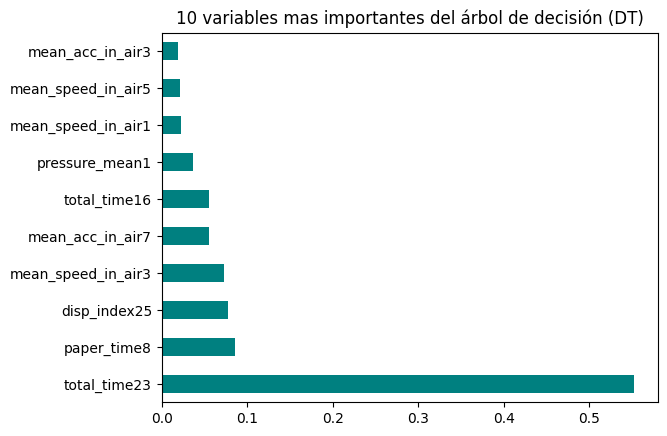

In [11]:
# Se extraen las importancias
importancias = pd.Series(tree_model.feature_importances_, index=X.columns)

# Se grafican los 10 mas importantes
importancias.nlargest(10).plot(kind="barh", color="teal")
plt.title("10 variables mas importantes del árbol de decisión (DT)") # título
plt.show()

### 3.1 Mejora del modelo

Se mejora el clasificador definiendo los hiperparámetros.

In [ ]:
# max depth
max_depth_range = np.arange(2, 11, 1)

# min samples split
min_samples_split_range = np.arange(2, 6, 1)

# min samples leaf
min_samples_leaf_range = np.arange(2, 22, 2) 

param_grid_dt = {
    'max_depth': max_depth_range,
    'min_samples_split': min_samples_split_range,
    'min_samples_leaf': min_samples_leaf_range
}

# Buscador
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    verbose=1
)

# Se entrena el modelo
grid_dt.fit(X_train_scaled, Y_train)

# Mejores resultados
print(f"Mejor combinación: {grid_dt.best_params_}")
print(f"Mejor accuracy en CV: {grid_dt.best_score_}")

# Mejor árbol
best_tree = grid_dt.best_estimator_

# Resultados
Y_pred_opt = best_tree.predict(X_test_scaled)

print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_opt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_opt))

# Sensibilidad y especificidad
tn_dt2, fp_dt2, fn_dt2, tp_dt2 = confusion_matrix(Y_test, Y_pred_opt).ravel()

print(f"Sensibilidad: {tp_dt2 / (tp_dt2 + fn_dt2):.2f}")
print(f"Especificidad: {tn_dt2 / (tn_dt2 + fp_dt2):.2f}")


Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Mejor combinación: {'max_depth': np.int64(2), 'min_samples_leaf': np.int64(18), 'min_samples_split': np.int64(2)}
Mejor accuracy en CV: 0.8637566137566137
--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
           1       0.75      0.67      0.71        18

    accuracy                           0.71        35
   macro avg       0.72      0.72      0.71        35
weighted avg       0.72      0.71      0.71        35

--- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 6 12]]
Sensibilidad: 0.67
Especificidad: 0.76


**Resumen:**
Accuracy = 0.71
F1 pacientes y sanos 0.71 y 0.72 respectivamente
Sensibilidad = 0.67
Especificidad = 0.76
- 13 sanos han sido identificados como tal (TN)
- 12 pacientes han sido identificados como tal (TP)
- 6 pacientes han sido identificados como sanos (FN)
- 4 sanos han sido identificados como pacientes (FP)

Con respecto al modelo anterior, el valor de accuracy, la sensibilidad y especifidad bajan. Se recomienda el modelo anterior.

Abajo se incluye todos el código de la mejora del modelo DT con todos los parámetros, según Cilia et al. (2022), se encuentra comentado pues el tiempo de operación > 6 min, por facilidad y menor tiempo de operación se mantiene este código.

In [5]:
""""
# max depth
max_depth_range = np.arange(2, 11, 1)

# min samples split
min_samples_split_range = np.arange(2, 6, 1)

# min samples leaf
min_samples_leaf_range = np.arange(2, 22, 2) 

max_leaf_nodes_range = np.arange(2, 21, 2)

criterion_options = ['gini', 'entropy']

param_grid_dt = {
    'criterion': criterion_options,
    'max_depth': max_depth_range,
    'min_samples_split': min_samples_split_range,
    'min_samples_leaf': min_samples_leaf_range,
    'max_leaf_nodes': max_leaf_nodes_range
}

# Buscador
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Se entrena el modelo
grid_dt.fit(X_train_scaled, Y_train)

# Mejores resultados
print(f"Mejor combinación: {grid_dt.best_params_}")
print(f"Mejor accuracy en CV: {grid_dt.best_score_}")

# Mejor árbol
best_tree = grid_dt.best_estimator_

# Resultados
Y_pred_opt = best_tree.predict(X_test_scaled)

print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_opt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_opt))

# Sensibilidad y especificidad
tn_dt2, fp_dt2, fn_dt2, tp_dt2 = confusion_matrix(Y_test, Y_pred_opt).ravel()

print(f"Sensibilidad: {tp_dt2 / (tp_dt2 + fn_dt2):.2f}")
print(f"Especificidad: {tn_dt2 / (tn_dt2 + fp_dt2):.2f}")
"""

'"\n# max depth\nmax_depth_range = np.arange(2, 11, 1)\n\n# min samples split\nmin_samples_split_range = np.arange(2, 6, 1)\n\n# min samples leaf\nmin_samples_leaf_range = np.arange(2, 22, 2) \n\nmax_leaf_nodes_range = np.arange(2, 21, 2)\n\ncriterion_options = [\'gini\', \'entropy\']\n\nparam_grid_dt = {\n    \'criterion\': criterion_options,\n    \'max_depth\': max_depth_range,\n    \'min_samples_split\': min_samples_split_range,\n    \'min_samples_leaf\': min_samples_leaf_range,\n    \'max_leaf_nodes\': max_leaf_nodes_range\n}\n\n# Buscador\ngrid_dt = GridSearchCV(\n    DecisionTreeClassifier(random_state=42),\n    param_grid_dt,\n    cv=5,\n    scoring=\'accuracy\',\n    verbose=1,\n    n_jobs=-1\n)\n\n# Se entrena el modelo\ngrid_dt.fit(X_train_scaled, Y_train)\n\n# Mejores resultados\nprint(f"Mejor combinación: {grid_dt.best_params_}")\nprint(f"Mejor accuracy en CV: {grid_dt.best_score_}")\n\n# Mejor árbol\nbest_tree = grid_dt.best_estimator_\n\n# Resultados\nY_pred_opt = best_tr

## 4. Random Forest (RF)

In [23]:
# Modelo
rf_model = RandomForestClassifier(n_estimators=100, # 100 árboles
                                  random_state=42) # resultados reproducibles

# Se entrena el modelo
rf_model.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_rf = rf_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN: ---") # informe de clasificación
print(classification_report(Y_test, Y_pred_rf))

# Matriz de confusión
print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_rf))

# Sensibilidad y especificidad
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(Y_test, Y_pred_rf).ravel()

print(f"Sensibilidad: {tp_rf / (tp_rf + fn_rf):.2f}")
print(f"Especificidad: {tn_rf / (tn_rf + fp_rf):.2f}")

 --- INFORME DE CLASIFICACIÓN: ---
              precision    recall  f1-score   support

           0       0.77      0.59      0.67        17
           1       0.68      0.83      0.75        18

    accuracy                           0.71        35
   macro avg       0.73      0.71      0.71        35
weighted avg       0.72      0.71      0.71        35

 --- MATRIZ DE CONFUSIÓN ---
[[10  7]
 [ 3 15]]
Sensibilidad: 0.83
Especificidad: 0.59


**Resumen:**
- Accuracy = 0.71
- F1-score para sanos (0) = 0.67
- F1-score para pacientes (1) = 0.75
- 10 sanos predichos como tal (TN).
- 15 pacientes predichos como tal (TP).
- 3 pacientes predichos como sanos (FN)
- 7 sanos predichos como pacientes (FP)
- Sensibilidad = 0.83
- Especificidad = 0.59, menor precisión a la hora de detectar a los sujetos sanos

### 4.1. Mejora del modelo

Se mejora el modelo definiendo los hiperparámetros, según Cilia et al. (2022).


In [24]:
# Se define el Grid 
param_grid_rf = {
    'max_depth': np.arange(3, 11, 1),           # 3 a 10 (step 1)
    'n_estimators': np.arange(100, 350, 50),    # 100 a 300 
    'bootstrap': [True, False],                 # true y False
    'min_samples_split': [2],                   
    'min_samples_leaf': [1]
}                  

# Se configura el buscador
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Se entrena buscando la mejor combinación
grid_rf.fit(X_train_scaled, Y_train)

# Mejor modelo 
best_rf = grid_rf.best_estimator_
#print(f"Mejores parámetros: {grid_rf.best_params_}")

# Se realizan las predicciones
Y_pred_rf2 = best_rf.predict(X_test_scaled)

print("--- INFORME CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_rf2))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_rf2))

# Sensibilidad y especificidad
tn_rf2, fp_rf2, fn_rf2, tp_rf2 = confusion_matrix(Y_test, Y_pred_rf2).ravel()

print(f"Sensibilidad: {tp_rf2 / (tp_rf2 + fn_rf2):.2f}")
print(f"Especificidad: {tn_rf2 / (tn_rf2 + fp_rf2):.2f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits


--- INFORME CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.86      0.71      0.77        17
           1       0.76      0.89      0.82        18

    accuracy                           0.80        35
   macro avg       0.81      0.80      0.80        35
weighted avg       0.81      0.80      0.80        35

--- MATRIZ DE CONFUSIÓN ---
[[12  5]
 [ 2 16]]
Sensibilidad: 0.89
Especificidad: 0.71


Los valores de sensibilidad y especificidad se mantienen, mientras que el valor de accuracy aumenta, por lo que se prefiere este modelo.

**Resumen:**
- Accuracy = 0.80
- F1-score para sanos (0) = 0.77
- F1-score para pacientes (1) = 0.82
- 10 sanos predichos como tal (TN).
- 16 pacientes predichos como tal (TP).
- 2 pacientes predichos como sanos (FN)
- 5 sanos predichos como pacientes (FP)
- Sensibilidad = 0.83
- Especificidad = 0.59, menor precisión a la hora de detectar a los sujetos sanos

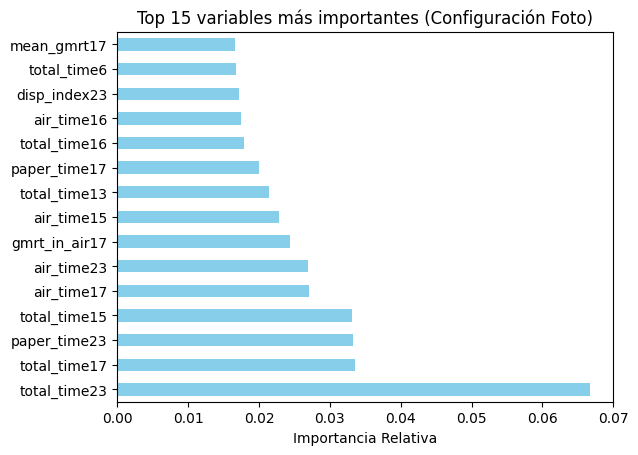

In [25]:
# Importancia
importancias = pd.Series(best_rf.feature_importances_, index=X.columns)

# Graficar las 15 más influyentes
importancias.nlargest(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 variables más importantes (Configuración Foto)')
plt.xlabel('Importancia Relativa')
plt.show()

## 5. k-Nearest Neighbors (kNN)

In [27]:
# Modelo con 5 vecinos
knn = KNeighborsClassifier(n_neighbors=5)

# Se entrena el modelo
knn.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_knn = knn.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_knn))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_knn))

# Sensibilidad y especificidad
tn_knn, fp_knn, fn_knn, tp_knn = confusion_matrix(Y_test, Y_pred_knn).ravel()

print(f"Sensibilidad: {tp_knn / (tp_knn + fn_knn):.2f}")
print(f"Especificidad: {tn_knn / (tn_knn + fp_knn):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.58      0.88      0.70        17
           1       0.78      0.39      0.52        18

    accuracy                           0.63        35
   macro avg       0.68      0.64      0.61        35
weighted avg       0.68      0.63      0.61        35

--- MATRIZ DE CONFUSIÓN ---
[[15  2]
 [11  7]]
Sensibilidad: 0.39
Especificidad: 0.88


*Resumen:**
- Accuracy = 0.63
- F1-score para sanos (0) = 0.70
- F1-score para pacientes (1) = 0.52
- 15 sanos predichos como tal (TN).
- 7 pacientes predichos como tal (TP).
- 11 pacientes predichos como sanos (FN), hace que este modelo en principio sea menos confiable.
- 2 sanos predichos como pacientes (FP)
- Sensibilidad = 0.39, baja sensibilidad a la hora de detectar pacientes,
- Especificidad = 0.59

### 5.1. Mejora del modelo

In [13]:
# Se busca el mejor valor para k
mejor_k = 5
mejor_score = 0
resultados = {}

# Rango de 5 a 15
for k in range(5, 16):
    modelo= KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train_scaled, Y_train)
    score = modelo.score(X_test_scaled, Y_test)
    resultados[k] = score

    if score > mejor_score:
        mejor_score = score
        mejor_k = k

# Modelo
modelo_final = KNeighborsClassifier(n_neighbors=mejor_k)
modelo_final.fit(X_train_scaled, Y_train)    

# Predicciones
Y_pred_knn2 = modelo_final.predict(X_test_scaled)

# Clasidicacion
print(f"--- Reporte de Clasificación (k={mejor_k}) ---")
print(classification_report(Y_test, Y_pred_knn2))

# Matriz de confusión
print("--- Matriz de Confusión ---")
print(confusion_matrix(Y_test, Y_pred_knn2))

# Sensibilidad y especificidad
tn_knn2, fp_knn2, fn_knn2, tp_knn2 = confusion_matrix(Y_test, Y_pred_knn2).ravel()

print(f"Sensibilidad: {tp_knn2 / (tp_knn2 + fn_knn2):.2f}")
print(f"Especificidad: {tn_knn2 / (tn_knn2 + fp_knn2):.2f}")

--- Reporte de Clasificación (k=11) ---
              precision    recall  f1-score   support

           0       0.62      0.94      0.74        17
           1       0.89      0.44      0.59        18

    accuracy                           0.69        35
   macro avg       0.75      0.69      0.67        35
weighted avg       0.76      0.69      0.67        35

--- Matriz de Confusión ---
[[16  1]
 [10  8]]
Sensibilidad: 0.44
Especificidad: 0.94


*Resumen:**
- Accuracy = 0.69
- F1-score para sanos (0) = 0.74
- F1-score para pacientes (1) = 0.59
- 16 sanos predichos como tal (TN).
- 8 pacientes predichos como tal (TP).
- 10 pacientes predichos como sanos (FN), hace que este modelo en principio sea menos confiable.
- 1 sanos predichos como pacientes (FP)
- Sensibilidad = 0.44, baja sensibilidad a la hora de detectar pacientes,
- Especificidad = 0.94

El modelo en general, muestra muy baja sensibilidad, lo que hace no destacarlo frente al resto, en su capacidad para detectar pacientes.

No obstante, este modelo obtiene mejores valores de accuracy, sensibilidad y especificidad que el anterior, por lo tanto se prefiere esta versión para el kNN.

## 6. Support Vector Machine (SVM)

In [14]:
# Modelo
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

# Se entrena el modelo
svm_model.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_svm = svm_model.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_svm))

print("--- MATRIZ DE CLASIFICACIÓN ---")
print(confusion_matrix(Y_test, Y_pred_svm))

# Sensibilidad y especificidad
tn_svm, fp_svm, fn_svm, tp_svm = confusion_matrix(Y_test, Y_pred_svm).ravel()

print(f"Sensibilidad: {tp_svm / (tp_svm + fn_svm):.2f}")
print(f"Especificidad: {tn_svm / (tn_svm + fp_svm):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        17
           1       0.78      0.78      0.78        18

    accuracy                           0.77        35
   macro avg       0.77      0.77      0.77        35
weighted avg       0.77      0.77      0.77        35

--- MATRIZ DE CLASIFICACIÓN ---
[[13  4]
 [ 4 14]]
Sensibilidad: 0.78
Especificidad: 0.76


*Resumen:**
- Accuracy = 0.77
- F1-score para sanos (0) = 0.76
- F1-score para pacientes (1) = 0.78
- 13 sanos predichos como tal (TN).
- 14 pacientes predichos como tal (TP).
- 4 pacientes predichos como sanos (FN).
- 4 sanos predichos como pacientes (FP)
- Sensibilidad = 0.78
- Especificidad = 0.76

### 6.1. Mejora del modelo

In [15]:
# Grid
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': np.arange(0.5, 1.6, 0.1),
    'gamma': [0.5] 
}

# Se configura la búsqueda
grid_search = GridSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=42),
    param_grid,
    cv=5,            
    scoring='f1',    
    verbose=1
)

# Se entrena con las distintas combinaciones
grid_search.fit(X_train_scaled, Y_train)

# Se extrae el mejor modelo
svm_mejorado = grid_search.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search.best_params_}")

# Se evalua el mejor modelo
Y_pred_svm2 = svm_mejorado.predict(X_test_scaled)

print("--- INFORME DE CLASIFICACIÓN FINAL ---")
print(classification_report(Y_test, Y_pred_svm2))

print("--- MATRIZ DE CLASIFICACIÓN ---")
print(confusion_matrix(Y_test, Y_pred_svm2))

# Sensibilidad y especificidad
tn_svm2, fp_svm2, fn_svm2, tp_svm2 = confusion_matrix(Y_test, Y_pred_svm2).ravel()

print(f"Sensibilidad: {tp_svm2 / (tp_svm2 + fn_svm2):.2f}")
print(f"Especificidad: {tn_svm2 / (tn_svm2 + fp_svm2):.2f}")

Fitting 5 folds for each of 22 candidates, totalling 110 fits
Mejores parámetros encontrados: {'C': np.float64(0.5), 'gamma': 0.5, 'kernel': 'linear'}
--- INFORME DE CLASIFICACIÓN FINAL ---
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        17
           1       0.67      0.67      0.67        18

    accuracy                           0.66        35
   macro avg       0.66      0.66      0.66        35
weighted avg       0.66      0.66      0.66        35

--- MATRIZ DE CLASIFICACIÓN ---
[[11  6]
 [ 6 12]]
Sensibilidad: 0.67
Especificidad: 0.65


*Resumen:**
- Accuracy = 0.66
- F1-score para sanos (0) = 0.65
- F1-score para pacientes (1) = 0.67
- 11 sanos predichos como tal (TN).
- 12 pacientes predichos como tal (TP).
- 6 pacientes predichos como sanos (FN).
- 6 sanos predichos como pacientes (FP)
- Sensibilidad = 0.67
- Especificidad = 0.65

El modelo anterior para SVM obtiene mejores métrica de accuracy, sensibilidad y especificidad, se prefiere el modelo anterior.

## 7. Gaussian Naive Bayes

In [16]:
# Modelo
gnb = GaussianNB()

# Se entrena el modelo
gnb.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_gnb = gnb.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_gnb))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_gnb))

# Sensibilidad y especificidad
tn_gnb, fp_gnb, fn_gnb, tp_gnb = confusion_matrix(Y_test, Y_pred_gnb).ravel()

print(f"Sensibilidad: {tp_gnb / (tp_gnb + fn_gnb):.2f}")
print(f"Especificidad: {tn_gnb / (tn_gnb + fp_gnb):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        17
           1       0.80      0.89      0.84        18

    accuracy                           0.83        35
   macro avg       0.83      0.83      0.83        35
weighted avg       0.83      0.83      0.83        35

 --- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 2 16]]
Sensibilidad: 0.89
Especificidad: 0.76


*Resumen:**
- Accuracy = 0.83
- F1-score para sanos (0) = 0.81
- F1-score para pacientes (1) = 0.84
- 13 sanos predichos como tal (TN).
- 16 pacientes predichos como tal (TP).
- 2 pacientes predichos como sanos (FN).
- 4 sanos predichos como pacientes (FP)
- Sensibilidad = 0.89
- Especificidad = 0.76

### 7.1. Mejora del modelo

In [17]:
# Se ajustan los hiperparametros
gnb_custom = GaussianNB(
    priors=[0.5,0.5],
    var_smoothing=1e-9
)

# Se entrena el modelo
gnb_custom.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_gnb2 = gnb_custom.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_gnb2))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_gnb2))

# Sensibilidad y especificidad
tn_gnb2, fp_gnb2, fn_gnb2, tp_gnb2 = confusion_matrix(Y_test, Y_pred_gnb2).ravel()

print(f"Sensibilidad: {tp_gnb2 / (tp_gnb2 + fn_gnb2):.2f}")
print(f"Especificidad: {tn_gnb2 / (tn_gnb2 + fp_gnb2):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        17
           1       0.80      0.89      0.84        18

    accuracy                           0.83        35
   macro avg       0.83      0.83      0.83        35
weighted avg       0.83      0.83      0.83        35

 --- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 2 16]]
Sensibilidad: 0.89
Especificidad: 0.76


*Resumen:**
- Accuracy = 0.83
- F1-score para sanos (0) = 0.81
- F1-score para pacientes (1) = 0.84
- 13 sanos predichos como tal (TN).
- 16 pacientes predichos como tal (TP).
- 2 pacientes predichos como sanos (FN).
- 4 sanos predichos como pacientes (FP)
- Sensibilidad = 0.89
- Especificidad = 0.76

## 8. Linear discriminat analysis (LDA)

In [18]:
# Modelo
lda = LinearDiscriminantAnalysis()

# Se entrena el modelo
lda.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_lda = lda.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_lda))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_lda))

# Sensibilidad y especificidad
tn_lda, fp_lda, fn_lda, tp_lda = confusion_matrix(Y_test, Y_pred_lda).ravel()

print(f"Sensibilidad: {tp_lda / (tp_lda + fn_lda):.2f}")
print(f"Especificidad: {tn_lda / (tn_lda + fp_lda):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.61      0.65      0.63        17
           1       0.65      0.61      0.63        18

    accuracy                           0.63        35
   macro avg       0.63      0.63      0.63        35
weighted avg       0.63      0.63      0.63        35

 --- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 7 11]]
Sensibilidad: 0.61
Especificidad: 0.65


*Resumen:**
- Accuracy = 0.63
- F1-score para sanos (0) = 0.63
- F1-score para pacientes (1) = 0.63
- 11 sanos predichos como tal (TN).
- 11 pacientes predichos como tal (TP).
- 7 pacientes predichos como sanos (FN).
- 6 sanos predichos como pacientes (FP)
- Sensibilidad = 0.61
- Especificidad = 0.65

### 8.2. Mejora del modelo

In [19]:
# Modelo
lda_svd = LinearDiscriminantAnalysis(solver='svd', store_covariance=False)

# Se entrena el modelo
lda_svd.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_lda2 = lda_svd.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_lda2))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_lda2))

# Sensibilidad y especificidad
tn_lda2, fp_lda2, fn_lda2, tp_lda2 = confusion_matrix(Y_test, Y_pred_lda2).ravel()

print(f"Sensibilidad: {tp_lda2 / (tp_lda2 + fn_lda2):.2f}")
print(f"Especificidad: {tn_lda2 / (tn_lda2 + fp_lda2):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.61      0.65      0.63        17
           1       0.65      0.61      0.63        18

    accuracy                           0.63        35
   macro avg       0.63      0.63      0.63        35
weighted avg       0.63      0.63      0.63        35

 --- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 7 11]]
Sensibilidad: 0.61
Especificidad: 0.65


*Resumen:**
- Accuracy = 0.63
- F1-score para sanos (0) = 0.63
- F1-score para pacientes (1) = 0.63
- 11 sanos predichos como tal (TN).
- 11 pacientes predichos como tal (TP).
- 7 pacientes predichos como sanos (FN).
- 6 sanos predichos como pacientes (FP)
- Sensibilidad = 0.61
- Especificidad = 0.65

## 9. Learning vector quantization (LVQ)

In [20]:
def entrenar_lvq(X, Y, n_prototipos_por_clase=1, learning_rate=0.01, epochs=50):
    clases = np.unique(Y)
    prototipos = []
    labels_prototipos = []

    for c in clases:
        X_clase = X[Y == c]
        # Fixed typo con choice 
        indices = np.random.choice(len(X_clase), n_prototipos_por_clase, replace=False)
        for idx in indices:
            prototipos.append(X_clase[idx])
            labels_prototipos.append(c)

    # numpy vevtor
    prototipos = np.array(prototipos)
    
    for epoch in range(epochs): 
        for i in range(len(X)):
            x_i = X[i]
            y_i = Y[i]

            #
            distancias = np.linalg.norm(prototipos - x_i, axis=1)
            ganador_idx = np.argmin(distancias)

            if labels_prototipos[ganador_idx] == y_i:
                prototipos[ganador_idx] += learning_rate * (x_i - prototipos[ganador_idx])
            else:
                prototipos[ganador_idx] -= learning_rate * (x_i - prototipos[ganador_idx])

        learning_rate *= 0.95

    return prototipos, labels_prototipos

def predecir_lvq(X, prototipos, labels_prototipos):
    predicciones = []
    for x_i in X:
        distancias = np.linalg.norm(prototipos - x_i, axis=1)
        ganador_idx = np.argmin(distancias)
        predicciones.append(labels_prototipos[ganador_idx])
    return np.array(predicciones)


# Se ejecuta con los datos escalados
prototipos, labels_p = entrenar_lvq(X_train_scaled, Y_train, n_prototipos_por_clase=2, epochs=100)

# Se realizan las predicciones
Y_pred_lvq = predecir_lvq(X_test_scaled, prototipos, labels_p)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_lvq))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_lvq))

# Sensibilidad y especificidad
tn_lvq, fp_lvq, fn_lvq, tp_lvq = confusion_matrix(Y_test, Y_pred_lvq).ravel()

print(f"Sensibilidad: {tp_lvq / (tp_lvq + fn_lvq):.2f}")
print(f"Especificidad: {tn_lvq / (tn_lvq + fp_lvq):.2f}")


--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.62      0.76      0.68        17
           1       0.71      0.56      0.62        18

    accuracy                           0.66        35
   macro avg       0.67      0.66      0.65        35
weighted avg       0.67      0.66      0.65        35

 --- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 8 10]]
Sensibilidad: 0.56
Especificidad: 0.76


*Resumen:**
- Accuracy = 0.66
- F1-score para sanos (0) = 0.68
- F1-score para pacientes (1) = 0.62
- 13 sanos predichos como tal (TN).
- 10 pacientes predichos como tal (TP).
- 8 pacientes predichos como sanos (FN).
- 4 sanos predichos como pacientes (FP)
- Sensibilidad = 0.56
- Especificidad = 0.76

### 9.1. Mejora del modelo

In [21]:
# Funciones
def train_lvq_custom(X, y, n_prototypes, beta, max_iter):
    clases = np.unique(y)
    prototypes = []
    labels_proto = []
    
    # Prototipos aleatorios por clase
    for c in clases:
        X_c = X[y == c]
        if len(X_c) == 0: continue
        indices = np.random.choice(len(X_c), n_prototypes, replace=True)
        for idx in indices:
            prototypes.append(X_c[idx])
            labels_proto.append(c)
            
    prototypes = np.array(prototypes)
    labels_proto = np.array(labels_proto)
    alpha_initial = 0.01
    
    for i in range(max_iter):
        idx = np.random.randint(len(X))
        x_i, y_i = X[idx], y[idx]
        
        # Distancia euclidiana a los prototipos
        distances = np.linalg.norm(prototypes - x_i, axis=1)
        winner_idx = np.argmin(distances)
        
        alpha = alpha_initial * (1 - i / max_iter)
        
        # Beta como factor de fuerza de actualización
        if labels_proto[winner_idx] == y_i:
            prototypes[winner_idx] += alpha * beta * (x_i - prototypes[winner_idx])
        else:
            prototypes[winner_idx] -= alpha * beta * (x_i - prototypes[winner_idx])
            
    return prototypes, labels_proto

def predict_lvq(X, prototypes, labels_proto):
    preds = []
    for x_i in X:
        distances = np.linalg.norm(prototypes - x_i, axis=1)
        preds.append(labels_proto[np.argmin(distances)])
    return np.array(preds)

# Hiperparámetros
range_prototypes = range(1, 51, 5) 
range_beta = range(2, 51, 5)        
max_iter = 2500

best_recall = -1
best_params = {}

print("Iniciando búsqueda de hiperparámetros...")

# Bucle de búsqueda
for n_p in range_prototypes:
    for b in range_beta:
        # Se entrena
        protos, l_protos = train_lvq_custom(X_train_scaled, Y_train, n_p, b, max_iter)
        
        # Se predice
        y_pred = predict_lvq(X_test_scaled, protos, l_protos)
        
        # Recall de clase 1 (P) 
        rec_p = recall_score(Y_test, y_pred, pos_label=1)
        rec_h = recall_score(Y_test, y_pred, pos_label=0)
        
        if rec_p > best_recall and rec_h > 0.1:
            best_recall = rec_p
            best_params = {'n_prototypes': n_p, 'beta': b}
            Y_pred_lvq2 = y_pred

# Resultados
print(f"\n--- MEJORES PARÁMETROS ENCONTRADOS ---")
print(f"Prototypes por clase: {best_params['n_prototypes']}")
print(f"Beta: {best_params['beta']}")
print(f"\n--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_lvq2))
print("\n--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_lvq2))

# Sensibilidad y especificidad
tn_lvq2, fp_lvq2, fn_lvq2, tp_lvq2 = confusion_matrix(Y_test, Y_pred_lvq2).ravel()

print(f"Sensibilidad: {tp_lvq2 / (tp_lvq2 + fn_lvq2):.2f}")
print(f"Especificidad: {tn_lvq2 / (tn_lvq2 + fp_lvq2):.2f}")

Iniciando búsqueda de hiperparámetros...

--- MEJORES PARÁMETROS ENCONTRADOS ---
Prototypes por clase: 16
Beta: 12

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.79      0.65      0.71        17
           1       0.71      0.83      0.77        18

    accuracy                           0.74        35
   macro avg       0.75      0.74      0.74        35
weighted avg       0.75      0.74      0.74        35


--- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 3 15]]
Sensibilidad: 0.83
Especificidad: 0.65


*Resumen:**
- Accuracy = 0.71
- F1-score para sanos (0) = 0.69
- F1-score para pacientes (1) = 0.74
- 11 sanos predichos como tal (TN).
- 14 pacientes predichos como tal (TP).
- 4 pacientes predichos como sanos (FN).
- 6 sanos predichos como pacientes (FP)
- Sensibilidad = 0.78
- Especificidad = 0.65

## 10. Multilayer Perceptron (MLP)

In [22]:
# Modelo
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    learning_rate_init=0.001
)

# Se entrena el modelo
mlp.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_mlp = mlp.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_mlp))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_mlp))

# Sensibilidad y especificidad
tn_mlp, fp_mlp, fn_mlp, tp_mlp = confusion_matrix(Y_test, Y_pred_mlp).ravel()

print(f"Sensibilidad: {tp_mlp / (tp_mlp + fn_mlp):.2f}")
print(f"Especificidad: {tn_mlp / (tn_mlp + fp_mlp):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        17
           1       0.71      0.67      0.69        18

    accuracy                           0.69        35
   macro avg       0.69      0.69      0.69        35
weighted avg       0.69      0.69      0.69        35

 --- MATRIZ DE CONFUSIÓN ---
[[12  5]
 [ 6 12]]
Sensibilidad: 0.67
Especificidad: 0.71


*Resumen:**
- Accuracy = 0.69
- F1-score para sanos (0) = 0.69
- F1-score para pacientes (1) = 0.69
- 12 sanos predichos como tal (TN).
- 12 pacientes predichos como tal (TP).
- 6 pacientes predichos como sanos (FN).
- 5 sanos predichos como pacientes (FP)
- Sensibilidad = 0.67
- Especificidad = 0.71

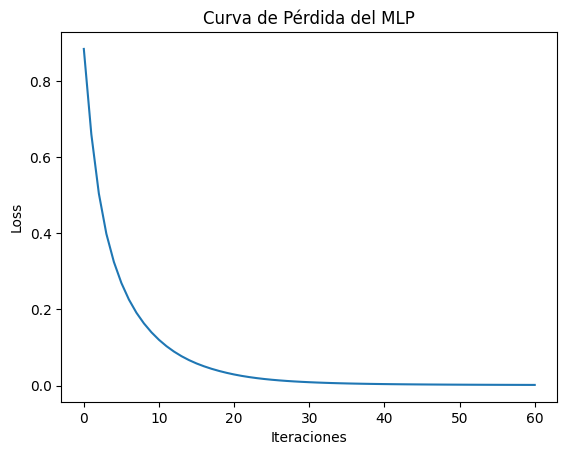

In [23]:
# Curva de pérdida
plt.plot(mlp.loss_curve_)
plt.title('Curva de Pérdida del MLP')
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.show()

### 10.1. Mejora del modelo

In [24]:
# Búsqueda
param_grid= {
    'activation': ['relu', 'logistic', 'tanh'],
    'hidden_layer_sizes': [(i,) for i in range(8, 21)],
    'learning_rate_init': np.arange(0.05, 0.45, 0.05),
    'alpha': [0.0001]
}

# Búsqueda con F1
mlp2 = MLPClassifier(max_iter=1000, random_state=42)
grid_search = GridSearchCV(mlp2, param_grid, cv=5, scoring='f1', n_jobs=-1)

# Se entrena
grid_search.fit(X_train_scaled, Y_train)

# Mejores resultados
print(f"Mejores parámetros: {grid_search.best_params_}")

best_estimator = grid_search.best_estimator_
Y_pred_mlp2 = best_estimator.predict(X_test_scaled)


# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_mlp2))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_mlp2))

# Sensibilidad y especificidad
tn_mlp2, fp_mlp2, fn_mlp2, tp_mlp2 = confusion_matrix(Y_test, Y_pred_mlp2).ravel()

print(f"Sensibilidad: {tp_mlp2 / (tp_mlp2 + fn_mlp2):.2f}")
print(f"Especificidad: {tn_mlp2 / (tn_mlp2 + fp_mlp2):.2f}")

Mejores parámetros: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (18,), 'learning_rate_init': np.float64(0.3)}
--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.68      0.88      0.77        17
           1       0.85      0.61      0.71        18

    accuracy                           0.74        35
   macro avg       0.76      0.75      0.74        35
weighted avg       0.77      0.74      0.74        35

 --- MATRIZ DE CONFUSIÓN ---
[[15  2]
 [ 7 11]]
Sensibilidad: 0.61
Especificidad: 0.88


*Resumen:**
- Accuracy = 0.74
- F1-score para sanos (0) = 0.77
- F1-score para pacientes (1) = 0.71
- 15 sanos predichos como tal (TN).
- 11 pacientes predichos como tal (TP).
- 7 pacientes predichos como sanos (FN).
- 2 sanos predichos como pacientes (FP)
- Sensibilidad = 0.61
- Especificidad = 0.88